## 1. Настройка и подключение к API

In [1]:
import os
from dotenv import load_dotenv
import requests
import pandas as pd
import time
from collections import Counter
import matplotlib.pyplot as plt

load_dotenv()

APP_ID = os.getenv("ADZUNA_APP_ID")
APP_KEY = os.getenv("ADZUNA_APP_KEY")


## 2. Сбор вакансий
Собираем вакансии по запросу "data scientist" через Adzuna API.

In [2]:
all_jobs = []

for page in range(1, 21):  # 20 страниц * 50
    params = {
        "app_id": APP_ID,
        "app_key": APP_KEY,
        "results_per_page": 50,
        "what": "data scientist",
        "content-type": "application/json"
    }
    url = f"https://api.adzuna.com/v1/api/jobs/nl/search/{page}"
    response = requests.get(url, params=params)
    
    if response.status_code != 200:
        print(f"Ошибка на странице {page}: {response.status_code}")
        break
    
    data = response.json()
    jobs = data.get("results", [])
    
    if not jobs:  # вакансии закончились
        print(f"Вакансии закончились на странице {page}")
        break
    
    all_jobs.extend(jobs)
    print(f"Страница {page}: получено {len(jobs)} вакансий, всего {len(all_jobs)}")
    
    time.sleep(1)  # пауза

print(f"\nИтого собрано: {len(all_jobs)} вакансий")

Страница 1: получено 50 вакансий, всего 50
Страница 2: получено 50 вакансий, всего 100
Страница 3: получено 50 вакансий, всего 150
Страница 4: получено 50 вакансий, всего 200
Страница 5: получено 37 вакансий, всего 237
Вакансии закончились на странице 6

Итого собрано: 237 вакансий


## 3. Превращение данных в таблицу

In [3]:
df = pd.DataFrame(all_jobs)
print(df.shape)
df.head()  # первые 5 строк

(237, 17)


,__CLASS__,adref,created,redirect_url,title,description,company,category,id,salary_is_predicted,location,longitude,latitude,contract_time,salary_min,salary_max,contract_type
0,Adzuna::API::Response::Job,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTUzNjAyNTEwMyIsI...,2025-12-10T11:00:24Z,https://www.adzuna.nl/land/ad/5536025103?se=vu...,Junior Data Scientist,Wij leiden jou op tot data-specialist! Ben jij...,"{'display_name': 'Veneficus', '__CLASS__': 'Ad...","{'label': 'IT ICT vacatures', 'tag': 'it-jobs'...",5536025103,0,"{'display_name': 'Nederland', 'area': ['Nederl...",NaN,NaN,NaN,NaN,NaN,NaN
1,Adzuna::API::Response::Job,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc0Nzk4MzA0MiIsI...,2026-06-01T21:04:12Z,https://www.adzuna.nl/land/ad/5747983042?se=vu...,Marine - Officier - Militair Jurist Data en AI,Introtekst Kun jij snel complexe vraagstukken ...,{'__CLASS__': 'Adzuna::API::Response::Company'...,"{'tag': 'unknown', 'label': 'Unknown', '__CLAS...",5747983042,0,"{'area': ['Nederland', 'Noord-Holland', 'Texel...",4.781200,52.956800,NaN,NaN,NaN,NaN
2,Adzuna::API::Response::Job,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTY4NjYyMjI1MiIsI...,2026-04-02T03:04:26Z,https://www.adzuna.nl/details/5686622252?utm_m...,Data Scientist,Ben jij een data scientist die energie haalt u...,"{'display_name': 'NN Group', '__CLASS__': 'Adz...",{'__CLASS__': 'Adzuna::API::Response::Category...,5686622252,0,"{'area': ['Nederland'], '__CLASS__': 'Adzuna::...",NaN,NaN,full_time,NaN,NaN,NaN
3,Adzuna::API::Response::Job,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTc3MDAxNDc3MyIsI...,2026-06-20T03:54:01Z,https://www.adzuna.nl/details/5770014773?utm_m...,Data Scientist,Job Description: Wil jij als Data Scientist we...,{'__CLASS__': 'Adzuna::API::Response::Company'...,"{'tag': 'unknown', 'label': 'Unknown', '__CLAS...",5770014773,0,{'__CLASS__': 'Adzuna::API::Response::Location...,NaN,NaN,full_time,NaN,NaN,NaN
4,Adzuna::API::Response::Job,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTU4NTI0MjMyMSIsI...,2026-01-15T01:19:23Z,https://www.adzuna.nl/details/5585242321?utm_m...,Data Scientist,"Tonnen aardappels verwerken, kilometers piepsc...",{'__CLASS__': 'Adzuna::API::Response::Company'...,{'__CLASS__': 'Adzuna::API::Response::Category...,5585242321,0,"{'display_name': 'Erp, Veghel', '__CLASS__': '...",5.534032,51.603642,NaN,42000.0,60000.0,NaN


In [4]:
df.to_csv("../data/raw_jobs.csv", index=False)

## 4. Очистка данных
Извлекаем название компании и локации из вложенных полей API.

In [5]:
df["company_name"] = df["company"].apply(lambda x: x.get("display_name") if isinstance(x, dict) else None)

df["location_name"] = df["location"].apply(lambda x: x.get("display_name") if isinstance(x, dict) else None)

df_clean = df[["title", "company_name", "location_name", "description", 
                "created", "salary_min", "salary_max", "contract_time", "redirect_url"]]

df_clean.head()

,title,company_name,location_name,description,created,salary_min,salary_max,contract_time,redirect_url
0,Junior Data Scientist,Veneficus,Nederland,Wij leiden jou op tot data-specialist! Ben jij...,2025-12-10T11:00:24Z,NaN,NaN,NaN,https://www.adzuna.nl/land/ad/5536025103?se=vu...
1,Marine - Officier - Militair Jurist Data en AI,Ministerie van Defensie,"Den Hoorn, Texel",Introtekst Kun jij snel complexe vraagstukken ...,2026-06-01T21:04:12Z,NaN,NaN,NaN,https://www.adzuna.nl/land/ad/5747983042?se=vu...
2,Data Scientist,NN Group,Nederland,Ben jij een data scientist die energie haalt u...,2026-04-02T03:04:26Z,NaN,NaN,full_time,https://www.adzuna.nl/details/5686622252?utm_m...
3,Data Scientist,dentsu,Nederland,Job Description: Wil jij als Data Scientist we...,2026-06-20T03:54:01Z,NaN,NaN,full_time,https://www.adzuna.nl/details/5770014773?utm_m...
4,Data Scientist,Eminent Groep,"Erp, Veghel","Tonnen aardappels verwerken, kilometers piepsc...",2026-01-15T01:19:23Z,42000.0,60000.0,NaN,https://www.adzuna.nl/details/5585242321?utm_m...


In [6]:
print(f"Всего вакансий: {len(df_clean)}")
print(f"С указанной зарплатой: {df_clean['salary_min'].notna().sum()}")

Всего вакансий: 237
С указанной зарплатой: 68


In [7]:
df_clean.to_csv("../data/clean_jobs.csv", index=False)

## 5. Фильтрация и удаление дублей
Оставляем только вакансии с "data scientist" в названии, убираем повторяющиеся объявления.

In [8]:
df_filtered = df_clean[df_clean["title"].str.contains("data scientist", case=False, na=False)]

print(f"До фильтрации: {len(df_clean)}")
print(f"После фильтрации по title: {len(df_filtered)}")

df_filtered = df_filtered.drop_duplicates(subset=["title", "company_name"])

print(f"После удаления дублей: {len(df_filtered)}")

df_filtered.to_csv("../data/filtered_jobs.csv", index=False)

До фильтрации: 237
После фильтрации по title: 47
После удаления дублей: 46


## 6. Извлечение навыков из описаний вакансий

In [9]:
skills_list = [
    "python", "sql", "spark", "airflow", "docker", "kubernetes",
    "aws", "azure", "gcp", "databricks",
    "tensorflow", "pytorch", "scikit-learn", "keras",
    "tableau", "power bi", "looker",
    "nlp", "generative ai", "llm", "machine learning", 
    "deep learning", "computer vision",
    "git", "ci/cd", "etl", "snowflake", "postgresql", "mongodb"
]

def extract_skills(description, skills=skills_list):
    if not isinstance(description, str):
        return []
    description = description.lower()
    return [s.strip() for s in skills if s in description]

df_filtered["skills"] = df_filtered["description"].apply(extract_skills)

df_filtered[["title", "company_name", "skills"]].head(10)

,title,company_name,skills
0,Junior Data Scientist,Veneficus,[]
2,Data Scientist,NN Group,[]
3,Data Scientist,dentsu,[]
4,Data Scientist,Eminent Groep,[]
5,Data Scientist,Action,[]
6,Data Scientist,Rado Bank,[]
7,Data Scientist,Openred,[]
8,Data scientist,DHD,[machine learning]
9,Data Scientist,In Person,[machine learning]
10,Data Scientist,Lanubia Consulting,[]


## 7. Анализ навыков на полном датасете
Считаем частоту навыков по всем вакансиям, чтобы получить более широкую статистику.

In [13]:
df_all = pd.read_csv("../data/clean_jobs.csv")
df_all["skills"] = df_all["description"].apply(extract_skills)

all_skills = [skill for sublist in df_all["skills"] for skill in sublist]
skill_counts = Counter(all_skills)

print(f"Вакансий с хотя бы одним найденным навыком: {sum(1 for s in df_all['skills'] if len(s) > 0)} из {len(df_all)}")
skill_counts.most_common(15)

Вакансий с хотя бы одним найденным навыком: 59 из 237


[('machine learning', 24),
 ('git', 16),
 ('generative ai', 12),
 ('python', 7),
 ('azure', 7),
 ('llm', 7),
 ('databricks', 6),
 ('nlp', 3),
 ('aws', 2),
 ('docker', 1),
 ('etl', 1),
 ('sql', 1),
 ('power bi', 1),
 ('kubernetes', 1),
 ('gcp', 1)]

## 8. Визуализация результатов

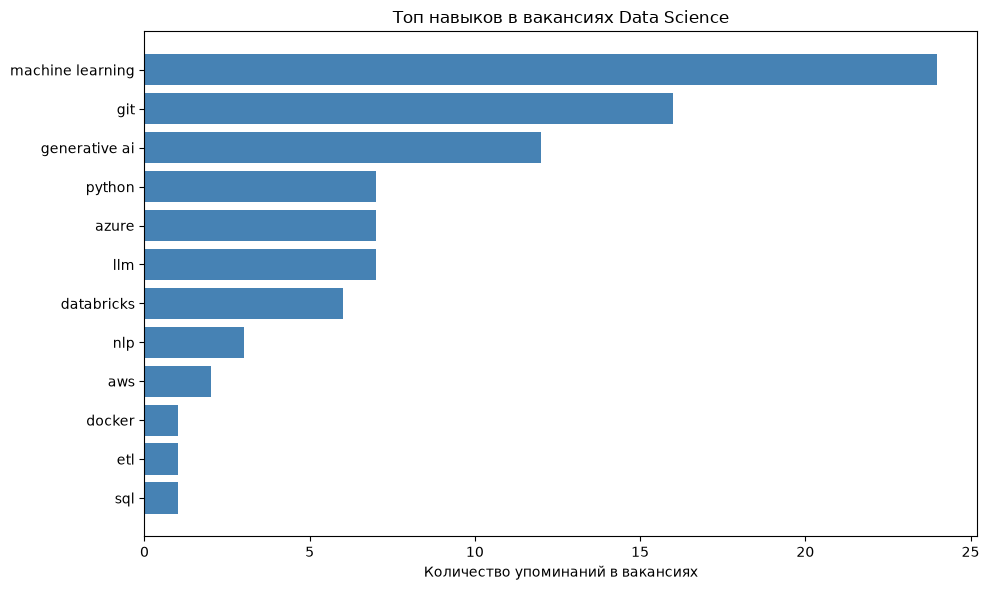

In [11]:
top_skills = skill_counts.most_common(12)
labels = [s[0] for s in top_skills]
values = [s[1] for s in top_skills]

plt.figure(figsize=(10, 6))
plt.barh(labels, values, color="steelblue")
plt.xlabel("Количество упоминаний в вакансиях")
plt.title("Топ навыков в вакансиях Data Science")
plt.gca().invert_yaxis()  # самый частый навык сверху
plt.tight_layout()
plt.savefig("../results/top_skills.png", dpi=150)
plt.show()